In [3]:
%pip install bioio bioio-sldy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 50.5 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 66.4 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 86.8 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ------------------------------

In [67]:
from bioio import BioImage
import bioio_sldy
import matplotlib.pyplot as plt
import numpy as np
import os
# Load the .sld file
filepath ="Z:\\DSR\\LMFACCHE\\lightmicro-inst_shortcuts\\001Facility Data\\Analysis Scripts\\Fiji macro\\Demo Data\\Slide2.sldy"
# "C:\\Users\\qlai\\Documents\\GitHub\\bioio-sldy\\bioio_sldy\\tests\\resources\\s1_t1_c2_z40.sldy"
# Extract the directory from the filepath
base_dir = os.path.dirname(filepath)
output_dir = os.path.join(base_dir, "ometiff")

# Create the ometiff folder if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

img = BioImage(filepath,reader=bioio_sldy.Reader)
print(img)

<BioImage [reader: bioio_sldy, image-in-memory: False]>


In [26]:

import tifffile

for scene_idx in range(len(img.scenes)):
    # Set the current scene
    img.set_scene(scene_idx)
    scene_name = img.current_scene
    print(f"Processing scene {scene_idx}: {scene_name}")

    # Extract metadata
    metadata = img.metadata

    # Extract pixel sizes (in micrometers)
    physical_pixel_sizes = img.physical_pixel_sizes
    lateral_pixel_size_x = physical_pixel_sizes.X  # X dimension
    lateral_pixel_size_y = physical_pixel_sizes.Y  # Y dimension
    axial_pixel_size = physical_pixel_sizes.Z  # Z dimension

    print(f"Lateral pixel size (X): {lateral_pixel_size_x} µm")
    print(f"Lateral pixel size (Y): {lateral_pixel_size_y} µm")
    print(f"Axial pixel size (Z): {axial_pixel_size} µm")

    # Extract time information from metadata if available
    if hasattr(metadata, 'time_captured'):
        print(f"Time captured: {metadata.time_captured}")
    if hasattr(metadata, 'time_interval'):
        print(f"Time interval: {metadata.time_interval}")

    # Export to OME-TIFF with metadata
    output_filename = f"scene_{scene_idx}_{scene_name}.ome.tiff"
    output_path = os.path.join(output_dir, output_filename)
    data = img.data

    tifffile.imwrite(
        output_path,
        data,
        photometric='minisblack',
        metadata={'axes': img.dims.order},
        description=str(metadata),
        resolution=(1/lateral_pixel_size_x, 1/lateral_pixel_size_y)
    )

    print(f"Exported {output_path}\n")

Processing scene 0: AS_TreatA-1769013428-656
Lateral pixel size (X): 0.1032 µm
Lateral pixel size (Y): 0.1032 µm
Axial pixel size (Z): None µm
Exported Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\ometiff\scene_0_AS_TreatA-1769013428-656.ome.tiff

Processing scene 1: AS_TreatB-1769013429-539
Lateral pixel size (X): 0.1032 µm
Lateral pixel size (Y): 0.1032 µm
Axial pixel size (Z): None µm
Exported Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\ometiff\scene_1_AS_TreatB-1769013429-539.ome.tiff



In [23]:
print(img.dimension_properties)
print(img.channel_names)
print(img.dims)

DimensionProperties(T=DimensionProperty(type=None, unit=None), C=DimensionProperty(type=None, unit=None), Z=DimensionProperty(type=None, unit=None), Y=DimensionProperty(type='space', unit=None), X=DimensionProperty(type='space', unit=None))
['0', '1', '2']
<Dimensions [T: 1, C: 3, Z: 1, Y: 1544, X: 1144]>


In [63]:
uncompressfile = "Z:\\DSR\\LMFACCHE\\lightmicro-inst_shortcuts\\001Facility Data\\Analysis Scripts\\Fiji macro\\Demo Data\\Slide2.dir"
from pathlib import Path

root = Path(uncompressfile)
npy_files = list(root.rglob("ImageData*.npy"))
print(f"Found {len(npyz_files)} .npy files")
for f in npy_files:
    print(f)

Found 6 .npy files
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2.dir\AS_TreatA-1769013428-656.imgdir\ImageData_Ch0_TP0000000.npy
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2.dir\AS_TreatA-1769013428-656.imgdir\ImageData_Ch1_TP0000000.npy
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2.dir\AS_TreatA-1769013428-656.imgdir\ImageData_Ch2_TP0000000.npy
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2.dir\AS_TreatB-1769013429-539.imgdir\ImageData_Ch0_TP0000000.npy
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2.dir\AS_TreatB-1769013429-539.imgdir\ImageData_Ch1_TP0000000.npy
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2.dir\AS_TreatB-1769013429-539.imgdir\I

In [64]:
import matplotlib.pyplot as plt
with open(npy_files[0], "rb") as f:
    print("First 300 bytes:", f.read(300).hex())
# Load the data
data = np.load(list(npy_files)[0], mmap_mode="r")
data.shape


First 300 bytes: 934e554d5059010056007b276465736372273a20273c7532272c2027666f727472616e5f6f72646572273a2046616c73652c20277368617065273a2028312c20313534342c2031313434292c207d20202020202020202020202020202020200a98007c009700a1009a008900a900a9008d0082009000970090008800a000a200a400a100b6009d00a400a900a9008c00b000af00a4009200ae009b00a700a1009e009b00a3009000bd009e009d00ab00b600a500b000a400a9009b00b100aa00a7009e00b600a600a10097009f00a4009e009e00aa009000af00b900a100c600b600b400c600990098009f00c3009c00b600c1009e00ac00a2009e00af00ad00b200b200a9009000ac00bb00ac00b9008e00af009d00a7009800ca0096009b00a400a700a600ad00ae009e00


(1, 1544, 1144)

ZstdError: zstd decompress error: Unknown frame descriptor

In [37]:
#Test loading .npyz
import zstandard as zstd
import numpy as np
import io

filepath ="Z:\\DSR\\LMFACCHE\\lightmicro-inst_shortcuts\\001Facility Data\\Analysis Scripts\\Fiji macro\\Demo Data\\Slide2-compressed.dir"
from pathlib import Path

root = Path(filepath)
npyz_files = list(root.rglob("*.npyz"))
print(f"Found {len(npyz_files)} .npyz files")
for f in npyz_files:
    print(f)


Found 6 .npyz files
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2-compressed.dir\AS_TreatA-1769013428-656.imgdir\ImageData_Ch0_TP0000000.npyz
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2-compressed.dir\AS_TreatA-1769013428-656.imgdir\ImageData_Ch1_TP0000000.npyz
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2-compressed.dir\AS_TreatA-1769013428-656.imgdir\ImageData_Ch2_TP0000000.npyz
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2-compressed.dir\AS_TreatB-1769013429-539.imgdir\ImageData_Ch0_TP0000000.npyz
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji macro\Demo Data\Slide2-compressed.dir\AS_TreatB-1769013429-539.imgdir\ImageData_Ch1_TP0000000.npyz
Z:\DSR\LMFACCHE\lightmicro-inst_shortcuts\001Facility Data\Analysis Scripts\Fiji

In [46]:
with open(npyz_files[0], "rb") as f:
    print("First 300 bytes:", f.read(300).hex())

First 300 bytes: 934e554d5059010156007b276465736372273a20273c7532272c2027666f727472616e5f6f72646572273a2046616c73652c20277368617065273a2028312c20313534342c2031313434292c207d20202020202020202020202020202020200a7000000000000000caae1f000000000028b52ffd805880e735000c86078e9286b61355c070646663f20f89fe43a27755eede33c618f3cccccccc0c22222200bfddc26fb7f05bab85df6ee11f8e0e0c8cd1d1d1c306b3622fb7f51f127d6a8265110441100441100485298aa228ba0ae3109bc8f20fcc2c05b211ef134914dfb7ce8b4ead184be8f1d1b5b3e2bdc675cbb59524ee93f3c888b1cac771eae1a52db5f372afdb3846e9e0c648e4f5bcc4d2748c54ace2608675d5c42947a7e87388474e89d95eb1c9854f645c13


In [58]:
import io
import ast
import numpy as np
import zstandard as zstd

ZSTD_MAGIC = b"\x28\xB5\x2F\xFD"

def load_sldy_npyz(path: str) -> np.ndarray:
    with open(path, "rb") as f:
        data = f.read()

    # --- 1) Verify and parse the fake “NUMPY” header ---
    if not data.startswith(b"\x93NUMPY"):
        raise ValueError("Not an SLDY .npyz (missing \\x93NUMPY header)")

    # Bytes 6..7 are the (nonstandard) "version" b'\x01\x01' (ignored)
    header_len = int.from_bytes(data[8:10], "little")
    header_start = 10
    header_end = header_start + header_len
    header_bytes = data[header_start:header_end]

    # The header is a Python dict-like string (not strict JSON)
    header_text = header_bytes.decode("latin1").strip()

    # Make it parseable: remove trailing commas before '}' if present
    # and trim to the last '}' in case extra padding got included.
    if "}" in header_text:
        header_text = header_text[: header_text.rfind("}") + 1]
    header_text = header_text.replace(", }", " }").rstrip(",")

    header = ast.literal_eval(header_text)  # {'descr': '<u2', 'fortran_order': False, 'shape': (1, 1544, 1144)}
    dtype = np.dtype(header["descr"])
    shape = tuple(header["shape"])
    expected_bytes = int(np.prod(shape)) * dtype.itemsize

    # --- 2) Find the actual start of the Zstd frame ---
    # There may be extra bytes between header and payload.
    zstd_start = data.find(ZSTD_MAGIC, header_end)
    if zstd_start == -1:
        # Helpful diagnostics
        context = data[header_end: header_end + 32].hex()
        raise ValueError(
            "Zstd magic not found after header. First 32 bytes after header: " + context
        )

    payload = data[zstd_start:]

    # --- 3A) Decompress using known output size (avoids the error) ---
    dctx = zstd.ZstdDecompressor()
    try:
        decompressed = dctx.decompress(payload, max_output_size=expected_bytes)
    except zstd.ZstdError:
        # --- 3B) Fallback: streaming decompression (works even when content size is unknown) ---
        with dctx.stream_reader(io.BytesIO(payload)) as reader:
            decompressed = reader.read()

    # Sanity-check the decompressed length
    if len(decompressed) != expected_bytes:
        raise ValueError(
            f"Decompressed size {len(decompressed)} does not match expected {expected_bytes} "
            f"for shape {shape} and dtype {dtype}"
        )

    # --- 4) Turn the bytes into a NumPy array ---
    arr = np.frombuffer(decompressed, dtype=dtype).reshape(shape)
    return arr

(1, 1544, 1144) uint16


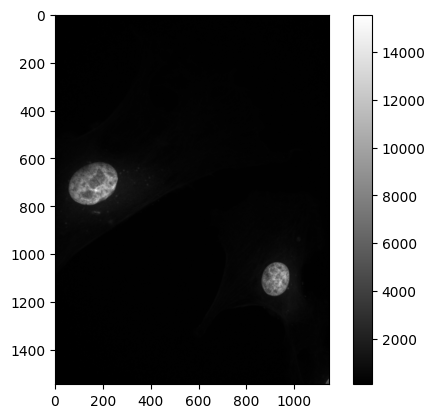

In [62]:
arr = load_sldy_npyz(npyz_files[0])
print(arr.shape, arr.dtype)
import matplotlib.pyplot as plt
plt.imshow(arr[0], cmap="gray")
plt.colorbar()
plt.show()


Image shape: (1, 3, 1, 1544, 1144)
Image dims: <Dimensions [T: 1, C: 3, Z: 1, Y: 1544, X: 1144]>
Physical pixel sizes: PhysicalPixelSizes(Z=None, Y=0.1032, X=0.1032)
Number of scenes: 2

Scene 0: AS_TreatA-1769013428-656
  Data shape: (1, 3, 1, 1544, 1144)
  Data dtype: uint16
  Data range: [41, 15560]


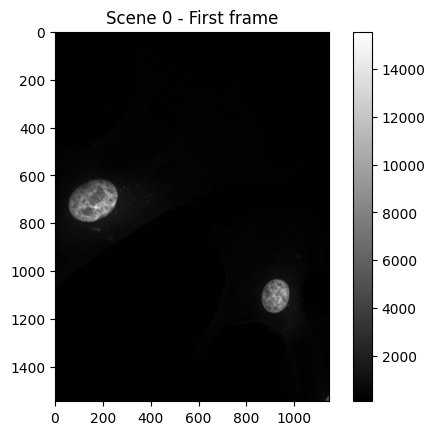


Scene 1: AS_TreatB-1769013429-539
  Data shape: (1, 3, 1, 1544, 1144)
  Data dtype: uint16
  Data range: [54, 20833]


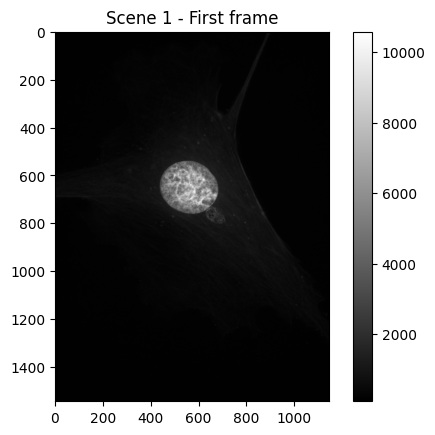

In [3]:
#Try it out
import pathlib
from bioio import BioImage
import bioio_sldy
import numpy as np

# Test with compressed .npyz file
compressed_path = "Z:\\DSR\\LMFACCHE\\lightmicro-inst_shortcuts\\001Facility Data\\Analysis Scripts\\Fiji macro\\Demo Data\\Slide2-compressed.sldyz"

# Load the image
img = BioImage(compressed_path, reader=bioio_sldy.Reader)

# Test basic properties
print(f"Image shape: {img.shape}")
print(f"Image dims: {img.dims}")
print(f"Physical pixel sizes: {img.physical_pixel_sizes}")
print(f"Number of scenes: {len(img.scenes)}")

# Test data loading for each scene
for scene_idx in range(len(img.scenes)):
    img.set_scene(scene_idx)
    print(f"\nScene {scene_idx}: {img.current_scene}")

    # Load data (tests get_data() method)
    data = img.data
    print(f"  Data shape: {data.shape}")
    print(f"  Data dtype: {data.dtype}")
    print(f"  Data range: [{data.min()}, {data.max()}]")

    # Visualize first frame of first channel
    import matplotlib.pyplot as plt
    plt.imshow(data[0, 0, 0], cmap='gray')
    plt.title(f"Scene {scene_idx} - First frame")
    plt.colorbar()
    plt.show()

In [2]:
# Test delayed loading
print("\nTesting delayed loading...")
sldy_reader = bioio_sldy.Reader(compressed_path)

# Access the internal _sldy_images attribute (note the underscore)
# Or better yet, use the reader's methods directly
img.set_scene(0)  # Use the BioImage object instead

# Get the underlying SldyImage object through the reader's internal structure
# The Reader class stores SldyImage objects but doesn't expose them directly

# Alternative approach: Access through the BioImage object
scene_img = img._xarray_dask_data  # or img._xarray_data

# Or simply test through the BioImage interface:
print("\nTesting data loading modes...")
data_delayed = img.get_image_dask_data("ZYX")  # Lazy loading
print(f"Delayed loading shape: {data_delayed.shape}")

data_eager = img.get_image_data("ZYX")  # Eager loading
print(f"Eager loading shape: {data_eager.shape}")


Testing delayed loading...

Testing data loading modes...
Delayed loading shape: (1, 1544, 1144)
Eager loading shape: (1, 1544, 1144)
